In [3]:
from pathlib import Path
import shutil
import zipfile
import os

inputs = Path("/kaggle/input")
destination = Path("/kaggle/working/BTP")

matches = list(inputs.rglob("run_public252.py"))

if matches:
    source = matches[0].parent
    shutil.copytree(source, destination, dirs_exist_ok=True)
else:
    archives = list(inputs.rglob("*.zip"))
    code_found = False

    for archive in archives:
        with zipfile.ZipFile(archive) as z:
            if "BTP/run_public252.py" in z.namelist():
                # Extract only our code archive.
                target = Path("/kaggle/working").resolve()
                for name in z.namelist():
                    if not (target / name).resolve().is_relative_to(target):
                        raise ValueError("Unsafe archive path")
                z.extractall(target)
                code_found = True
                break

    if not code_found:
        print("Attached input folders:", list(inputs.iterdir()))
        print("ZIP files found:", archives)
        raise RuntimeError(
            "BTP code is not attached. Add the dataset containing BTP-code.zip."
        )

assert (destination / "run_public252.py").is_file()
os.chdir(destination)
print("Code ready:", os.getcwd())

Code ready: /kaggle/working/BTP


In [5]:
import importlib
from pathlib import Path

for name in [
    "torch", "torchvision", "numpy", "pandas",
    "scipy", "skimage", "PIL", "einops", "torchmetrics", "tqdm"
]:
    try:
        module = importlib.import_module(name)
        print(f"{name}: OK ({getattr(module, '__version__', 'unknown')})")
    except Exception as error:
        print(f"{name}: FAILED — {error}")

import torch
print("\nCUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(
        torch.cuda.get_device_properties(0).total_memory / 1024**3, 1
    ), "GB")

roots = [
    p.parent
    for p in Path("/kaggle/input").rglob("train_data.csv")
    if (p.parent / "visible_28").is_dir()
    and (p.parent / "labels").is_dir()
]

print("\nPrepared dataset folders:", roots)

torch: OK (2.10.0+cpu)
torchvision: OK (0.25.0+cpu)
numpy: OK (2.0.2)
pandas: OK (2.3.3)
scipy: OK (1.16.3)
skimage: OK (0.25.2)
PIL: OK (11.3.0)
einops: OK (0.8.2)
torchmetrics: OK (1.9.0)
tqdm: OK (4.67.3)

CUDA available: False

Prepared dataset folders: [PosixPath('/kaggle/input/datasets/arnavnigamd/btp-data/public252')]


In [6]:
from pathlib import Path
import subprocess
import sys

DATA_ROOT = Path("/kaggle/input/datasets/arnavnigamd/btp-data/public252")

def run(script, *args):
    subprocess.run(
        [sys.executable, script, *map(str, args)],
        cwd="/kaggle/working/BTP",
        check=True,
    )

run("verify_evaluation.py")
run("run_public252.py", "--root", DATA_ROOT)
run("verify_portability.py", "--root", DATA_ROOT)
run("verify_public252_pipeline.py", "--root", DATA_ROOT)

Evaluated 1/2
Evaluated 2/2
PASS: production CPU evaluation, MSE/PSNR, confusion matrix, scene IDs, no default cubes, nonfinite rejection and three checkpoint formats
{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "public252_v1_baseline",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/BTP/exp/CRSDUN/"
  ],
  "note": "Header/membership checks plus one trainin

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
import subprocess
import sys
from datetime import datetime

DATA_ROOT = "/kaggle/input/datasets/arnavnigamd/btp-data/public252"
OUT = "/kaggle/working/gpu_smoke_" + datetime.now().strftime("%Y%m%d_%H%M%S")

subprocess.run(
    [
        sys.executable, "gpu_smoke.py",
        "--root", DATA_ROOT,
        "--out", OUT,
    ],
    cwd="/kaggle/working/BTP",
    check=True,
)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


{
  "status": "passed",
  "scene": "2021-11-03_007",
  "loss": 1.664834976196289,
  "optimizer_updates": 1,
  "checkpoint_reload": true,
  "peak_cuda_allocated_gib": 7.195286750793457,
  "scope": "One crop; not a passed overfit test or full-resolution validation memory benchmark"
}


CompletedProcess(args=['/usr/bin/python3', 'gpu_smoke.py', '--root', '/kaggle/input/datasets/arnavnigamd/btp-data/public252', '--out', '/kaggle/working/gpu_smoke_20260917_144736'], returncode=0)

In [5]:
import subprocess
import sys
from datetime import datetime

OUT = "/kaggle/working/fixed_crop_" + datetime.now().strftime("%Y%m%d_%H%M%S")

subprocess.run(
    [
        sys.executable, "diagnostic_public252.py",
        "--root", "/kaggle/input/datasets/arnavnigamd/btp-data/public252",
        "--out", OUT,
        "--transpose-image",
        "--steps", "200",
    ],
    cwd="/kaggle/working/BTP",
    check=True,
)

print("Diagnostic results:", OUT)

Audit train: 25/202
Audit train: 50/202
Audit train: 75/202
Audit train: 100/202
Audit train: 125/202
Audit train: 150/202
Audit train: 175/202
Audit train: 200/202
Audit val: 25/25
{
  "split_sizes": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "scene_id_overlap": false,
  "test_pixels_read": false,
  "note": "Scene IDs checked; related-scene/group leakage not established by this audit.",
  "splits": {
    "train": {
      "pixel_counts": [
        50219622,
        64424,
        71443,
        225719,
        237011,
        111273,
        95076,
        197231,
        281508,
        97451,
        85906,
        59143,
        54898,
        299937,
        185704,
        259014,
        30990,
        94627,
        86883,
        92059,
        57394,
        5749,
        40026
      ],
      "missing_classes": [],
      "foreground_fraction": 0.051620521167717356,
      "image_min": 0.0,
      "image_max": 8.81400919018774,
      "sampled_crop_foreground_quantil

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


{"step": 0, "elapsed_seconds": 5.82325291633606, "ce": 3.153074860572815, "mse": 0.6100774705410004, "foreground_miou_present": 0.010282459926370188, "foreground_recall": 0.04205192751448258, "predicted_foreground_fraction": 0.9991226196289062, "prediction_counts": [115, 7, 6134, 1996, 15481, 47393, 17, 0, 79, 1591, 42866, 1, 2, 8, 15165, 10, 10, 179, 4, 0, 13, 0, 1], "iou_by_class": [0.0015917575897895985, 0.0, 0.0, 0.0, 0.0, 0.02148049554622709, 0.0, 0.0, 0.0, 0.0, 0.029893299926562703, 0.0, 0.0, 0.0, 0.010320964085431332, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}
Completed step 1/200; elapsed 14.6s
Completed step 2/200; elapsed 15.8s
Completed step 3/200; elapsed 16.8s
Completed step 4/200; elapsed 17.9s
Completed step 5/200; elapsed 18.9s
Completed step 6/200; elapsed 20.0s
Completed step 7/200; elapsed 21.1s
Completed step 8/200; elapsed 22.1s
Completed step 9/200; elapsed 23.2s
Completed step 10/200; elapsed 24.2s
{"step": 10, "elapsed_seconds": 24.864957571029663, "ce": 2.1827991

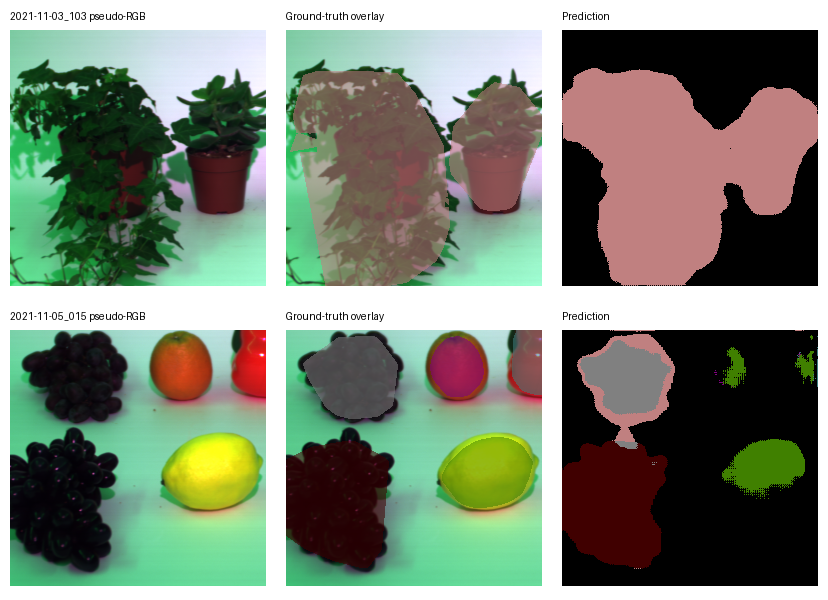

In [8]:
from IPython.display import display, Image

display(Image(
    filename="/kaggle/working/fixed_crop_20260917_144904/predictions.png"
))

In [7]:
import subprocess
import sys
from datetime import datetime

OUT = "/kaggle/working/fixed_crop_1000_" + datetime.now().strftime("%Y%m%d_%H%M%S")

subprocess.run(
    [
        sys.executable, "diagnostic_public252.py",
        "--root", "/kaggle/input/datasets/arnavnigamd/btp-data/public252",
        "--out", OUT,
        "--transpose-image",
        "--steps", "1000",
    ],
    cwd="/kaggle/working/BTP",
    check=True,
)

print("Results:", OUT)

Audit train: 25/202
Audit train: 50/202
Audit train: 75/202
Audit train: 100/202
Audit train: 125/202
Audit train: 150/202
Audit train: 175/202
Audit train: 200/202
Audit val: 25/25
{
  "split_sizes": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "scene_id_overlap": false,
  "test_pixels_read": false,
  "note": "Scene IDs checked; related-scene/group leakage not established by this audit.",
  "splits": {
    "train": {
      "pixel_counts": [
        50219622,
        64424,
        71443,
        225719,
        237011,
        111273,
        95076,
        197231,
        281508,
        97451,
        85906,
        59143,
        54898,
        299937,
        185704,
        259014,
        30990,
        94627,
        86883,
        92059,
        57394,
        5749,
        40026
      ],
      "missing_classes": [],
      "foreground_fraction": 0.051620521167717356,
      "image_min": 0.0,
      "image_max": 8.81400919018774,
      "sampled_crop_foreground_quantil

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


{"step": 0, "elapsed_seconds": 5.797361135482788, "ce": 3.153074860572815, "mse": 0.6100774705410004, "foreground_miou_present": 0.010282459926370188, "foreground_recall": 0.04205192751448258, "predicted_foreground_fraction": 0.9991226196289062, "prediction_counts": [115, 7, 6134, 1996, 15481, 47393, 17, 0, 79, 1591, 42866, 1, 2, 8, 15165, 10, 10, 179, 4, 0, 13, 0, 1], "iou_by_class": [0.0015917575897895985, 0.0, 0.0, 0.0, 0.0, 0.02148049554622709, 0.0, 0.0, 0.0, 0.0, 0.029893299926562703, 0.0, 0.0, 0.0, 0.010320964085431332, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}
Completed step 1/1000; elapsed 14.6s
Completed step 2/1000; elapsed 15.7s
Completed step 3/1000; elapsed 16.8s
Completed step 4/1000; elapsed 17.9s
Completed step 5/1000; elapsed 18.9s
Completed step 6/1000; elapsed 20.0s
Completed step 7/1000; elapsed 21.1s
Completed step 8/1000; elapsed 22.1s
Completed step 9/1000; elapsed 23.2s
Completed step 10/1000; elapsed 24.3s
{"step": 10, "elapsed_seconds": 24.91648244857788, "ce":

Final step: 1000
Final mIoU: 0.5775827666973424


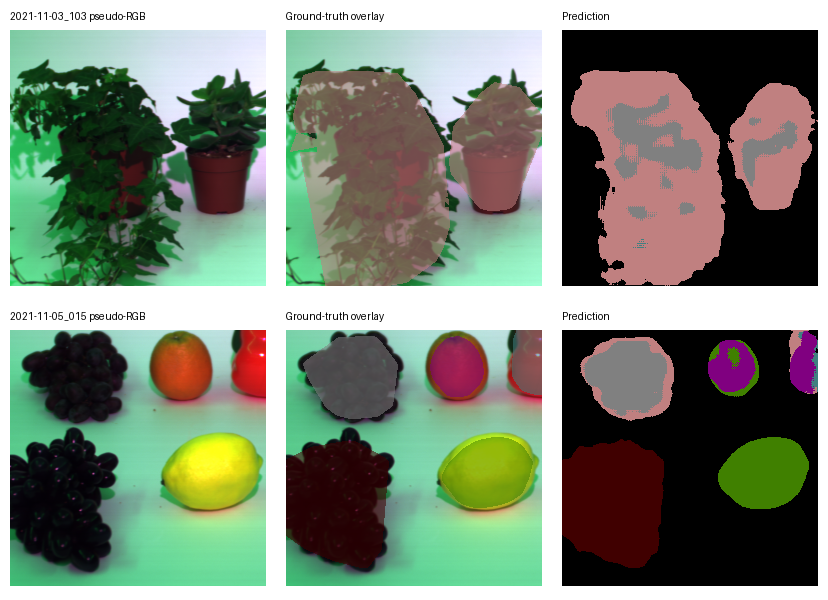

In [9]:
from pathlib import Path
from IPython.display import display, Image
import json

run_dir = Path("/kaggle/working/fixed_crop_1000_20260917_145850")

metrics = json.loads((run_dir / "metrics.json").read_text())
print("Final step:", metrics[-1]["step"])
print("Final mIoU:", metrics[-1]["foreground_miou_present"])

display(Image(filename=str(run_dir / "predictions.png")))

In [10]:
from pathlib import Path
import shutil
from IPython.display import FileLink, display

run_dir = Path("/kaggle/working/fixed_crop_1000_20260917_145850")
assert run_dir.is_dir(), "Run folder not found"

archive = shutil.make_archive(
    "/kaggle/working/fixed_crop_1000_backup",
    "zip",
    root_dir=run_dir.parent,
    base_dir=run_dir.name,
)

display(FileLink(archive))

/kaggle/working/fixed_crop_1000_backup.zip

##version 2

In [3]:
from pathlib import Path
import shutil, zipfile, os

inputs = Path('/kaggle/input')
working = Path('/kaggle/working')

def safe_extract(archive, target):
    target.mkdir(parents=True, exist_ok=False)
    with zipfile.ZipFile(archive) as z:
        for name in z.namelist():
            if not (target / name).resolve().is_relative_to(target.resolve()):
                raise ValueError('Unsafe ZIP member')
        z.extractall(target)

code = list(inputs.rglob('compare_diagnostic_lr.py'))
if not code:
    for archive in inputs.rglob('*.zip'):
        with zipfile.ZipFile(archive) as z:
            is_code = 'BTP/compare_diagnostic_lr.py' in z.namelist()
        if is_code:
            target = working / 'lr_code_unpacked'
            safe_extract(archive, target)
            code.extend(target.rglob('compare_diagnostic_lr.py'))
assert len(code) == 1, f'Expected one updated code input: {code}'
shutil.copytree(code[0].parent, working/'BTP', dirs_exist_ok=True)
os.chdir(working/'BTP')

run_name = 'fixed_crop_1000_20260917_145850'
runs = [p.parent for p in inputs.rglob('diagnostic_checkpoint.pt')
        if p.parent.name == run_name]
if not runs:
    for archive in inputs.rglob('*.zip'):
        with zipfile.ZipFile(archive) as z:
            is_run = f'{run_name}/diagnostic_checkpoint.pt' in z.namelist()
        if is_run:
            target = working / 'reference_unpacked'
            safe_extract(archive, target)
            runs.append(target/run_name)
assert len(runs) == 1, f'Expected one saved 1,000-step run: {runs}'
REFERENCE_RUN = runs[0]
DATA_ROOT = Path('/kaggle/input/datasets/arnavnigamd/btp-data/public252')
assert (DATA_ROOT/'train_data.csv').is_file()
print('Code ready; reference:', REFERENCE_RUN)

Code ready; reference: /kaggle/input/datasets/arnavnigamd/checkpoint1/fixed_crop_1000_20260917_145850


In [4]:
import subprocess
import sys
import torch
from pathlib import Path
from datetime import datetime

assert torch.cuda.is_available(), "Enable GPU T4 ×2 first"

DATA_ROOT = Path("/kaggle/input/datasets/arnavnigamd/btp-data/public252")
REFERENCE_RUN = Path(
    "/kaggle/input/datasets/arnavnigamd/checkpoint1/"
    "fixed_crop_1000_20260917_145850"
)
OUT = Path(
    "/kaggle/working/lr_comparison_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
)

subprocess.run(
    [sys.executable, "verify_diagnostic_comparison.py"],
    cwd="/kaggle/working/BTP",
    check=True,
)

subprocess.run(
    [
        sys.executable, "compare_diagnostic_lr.py",
        "--root", str(DATA_ROOT),
        "--from-run", str(REFERENCE_RUN),
        "--out", str(OUT),
        "--steps", "500",
        "--eval-every", "10",
    ],
    cwd="/kaggle/working/BTP",
    check=True,
)

print("Results:", OUT)
print((OUT / "comparison_summary.json").read_text())

PASS: actual Adam updates counted, AMP overflow skips detected without parameter changes, present-class metrics correct


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


{"arm": "control_4e-4", "ce": 0.2876781225204468, "mse": 0.00034684472484514117, "foreground_miou_present": 0.5775827666973424, "foreground_recall": 0.7766051862968163, "iou_by_class": [0.9293838219326819, 0.0, 0.0, 0.0, 0.0, 0.449001914137271, 0.0, 0.38253549868208486, 0.9758269720101781, 0.0, 0.8522586359610275, 0.0, 0.0, 0.0, 0.11549139367018323, 0.6903821857233101, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "prediction_counts": [73056, 0, 0, 0, 0, 2808, 0, 10282, 10894, 0, 5640, 0, 0, 0, 239, 28153, 0, 0, 0, 0, 0, 0, 0], "step": 1000, "additional_attempts": 0, "effective_updates": 0, "skipped_updates": 0, "amp_scale": 32768.0, "elapsed_seconds": 7.275676250457764}
{"arm": "control_4e-4", "ce": 0.28281502425670624, "mse": 0.00034214399056509137, "foreground_miou_present": 0.5854210829978076, "foreground_recall": 0.7803972825999258, "iou_by_class": [0.9304386774526304, 0.0, 0.0, 0.0, 0.0, 0.4592094196804037, 0.0, 0.38560277536860366, 0.9756407925831667, 0.0, 0.8670039754246477, 0.0, 0.0, 0.

In [5]:
import subprocess
import sys
from datetime import datetime

checkpoint = (
    "/kaggle/working/lr_comparison_20260917_160952/"
    "control_4e-4/diagnostic_checkpoint.pt"
)

subprocess.run(
    [
        sys.executable, "test.py",
        "--data_root",
        "/kaggle/input/datasets/arnavnigamd/btp-data/public252",
        "--transpose_image",
        "--eval_split", "val",
        "--limit", "1",
        "--pretrained_model_path", checkpoint,
        "--outf", "/kaggle/working/evaluations",
        "--name", "full_frame_smoke_" + datetime.now().strftime("%H%M%S"),
    ],
    cwd="/kaggle/working/BTP",
    check=True,
)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


load model from /kaggle/working/lr_comparison_20260917_160952/control_4e-4/diagnostic_checkpoint.pt
Evaluated 1/1
Completed val: 1 scenes. Results: /kaggle/working/evaluations/full_frame_smoke_163634/smoke_val


CompletedProcess(args=['/usr/bin/python3', 'test.py', '--data_root', '/kaggle/input/datasets/arnavnigamd/btp-data/public252', '--transpose_image', '--eval_split', 'val', '--limit', '1', '--pretrained_model_path', '/kaggle/working/lr_comparison_20260917_160952/control_4e-4/diagnostic_checkpoint.pt', '--outf', '/kaggle/working/evaluations', '--name', 'full_frame_smoke_163634'], returncode=0)

In [1]:
from pathlib import Path
from IPython.display import display, Image

comparison = Path("/kaggle/working/lr_comparison_20260917_160952")

for arm in ["control_4e-4", "low_4e-5"]:
    path = comparison / arm / "best_predictions.png"
    print(arm)
    if path.is_file():
        display(Image(filename=str(path)))
    else:
        print("Restore the saved comparison folder and update its path.")

control_4e-4
Restore the saved comparison folder and update its path.
low_4e-5
Restore the saved comparison folder and update its path.


In [3]:
from pathlib import Path

for root in [Path("/kaggle/input"), Path("/kaggle/working")]:
    print(f"\nSearching {root}")
    for pattern in ["best_predictions.png", "comparison_summary.json", "*.zip"]:
        for path in root.rglob(pattern):
            print(path)


Searching /kaggle/input
/kaggle/input/datasets/arnavnigamd/sddndwd/comparison_summary.json

Searching /kaggle/working


In [5]:
from pathlib import Path
import shutil
import zipfile

inputs = Path("/kaggle/input")
target = Path("/kaggle/working/BTP")

# Find an already-extracted copy of the updated code.
sources = [
    p.parent for p in inputs.rglob("run_public252.py")
    if "--stop-after-epoch" in p.read_text()
]

if sources:
    shutil.copytree(sources[0], target, dirs_exist_ok=True)
else:
    candidates = []
    for archive in inputs.rglob("*.zip"):
        if not zipfile.is_zipfile(archive):
            continue
        with zipfile.ZipFile(archive) as z:
            name = "BTP/run_public252.py"
            if name in z.namelist():
                if b"--stop-after-epoch" in z.read(name):
                    candidates.append(archive)

    if not candidates:
        raise FileNotFoundError(
            "Attach BTP-code-pilot.zip through Add Input, then rerun this cell."
        )

    with zipfile.ZipFile(candidates[0]) as z:
        destination = Path("/kaggle/working").resolve()
        for member in z.infolist():
            resolved = (destination / member.filename).resolve()
            if not resolved.is_relative_to(destination):
                raise ValueError("Unsafe archive path")
        z.extractall(destination)

assert (target / "run_public252.py").is_file()
assert "--stop-after-epoch" in (target / "run_public252.py").read_text()
print("Updated pilot code ready:", target)

Updated pilot code ready: /kaggle/working/BTP


In [6]:
from pathlib import Path
import subprocess, sys, torch
CODE = Path('/kaggle/working/BTP')
DATA = Path('/kaggle/input/datasets/arnavnigamd/btp-data/public252')
assert CODE.joinpath('run_public252.py').is_file(), 'Extract the updated BTP-code-pilot.zip first.'
assert '--stop-after-epoch' in CODE.joinpath('run_public252.py').read_text(), 'Use the updated pilot code ZIP.'
assert torch.cuda.is_available(), 'Enable the GPU before starting.'
print(torch.cuda.get_device_name(0))
subprocess.run([sys.executable, 'run_public252.py', '--root', str(DATA), '--epochs', '500', '--stop-after-epoch', '3'], cwd=CODE, check=True)


Tesla T4
{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "public252_v1_baseline",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/BTP/exp/CRSDUN/",
    "--stop_after_epoch",
    "3"
  ],
  "note": "Header/membership checks plus one training-scene loader check; full pixel audit is recorded separately."
}


CompletedProcess(args=['/usr/bin/python3', 'run_public252.py', '--root', '/kaggle/input/datasets/arnavnigamd/btp-data/public252', '--epochs', '500', '--stop-after-epoch', '3'], returncode=0)

In [7]:
from datetime import datetime
import shutil, zipfile
from IPython.display import display, FileLink
NAME = 'baseline_pilot_' + datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT = Path('/kaggle/working/baseline_runs')
RUN = OUTPUT / NAME
try:
    subprocess.run([sys.executable, '-u', 'run_public252.py', '--root', str(DATA),
        '--train', '--epochs', '500', '--stop-after-epoch', '3', '--batch-size', '1',
        '--workers', '0', '--output', str(OUTPUT), '--name', NAME], cwd=CODE, check=True)
finally:
    if RUN.exists():
        archive = shutil.make_archive(str(Path('/kaggle/working') / NAME), 'zip', root_dir=OUTPUT, base_dir=NAME)
        with zipfile.ZipFile(archive) as z:
            assert z.testzip() is None, 'Archive integrity check failed'
            required = [NAME + '/model/' + f for f in ['last.pt', 'best_iou.pth', 'best_psnr.pth']]
            missing = [f for f in required if f not in z.namelist()]
        print('Archive:', archive, 'bytes:', Path(archive).stat().st_size)
        print('Missing checkpoint files:', missing)
        display(FileLink(archive))
        print('Download this archive before stopping the session. If checkpoint files are missing, report the training error.')


{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "baseline_pilot_20260917_190720",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/baseline_runs/",
    "--stop_after_epoch",
    "3"
  ],
  "note": "Header/membership checks plus one training-scene loader check; full pixel audit is recorded separately."
}
Namespace(gpu_id='0', data_root='/kaggle/input/datasets/ar

2026-09-17 19:13:42,671 - INFO: Rec loss: 0.1178983703559947
2026-09-17 19:13:42,671 - INFO: Seg loss: 5.259866261246181
2026-09-17 19:13:42,671 - INFO: λ_rec: 1
2026-09-17 19:13:42,671 - INFO: λ_seg: 0.0001
2026-09-17 19:15:18,233 - INFO: -------------------Epoch: 1------------------------
2026-09-17 19:15:18,242 - INFO: 
Validation stats:
        PSNR      SSIM       MSE
0  20.421448  0.601779  0.009149
2026-09-17 19:15:18,249 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.964125  0.981685  0.964427  0.999675  0.964587
real potato   0.000000  0.000000  0.000000  0.000000  0.998803
fake potato   0.000000  0.000000  0.000000  0.000000  0.999272
real apple    0.054307  0.102970  0.087553  0.125122  0.992483
fake apple    0.001560  0.003112  0.129139  0.001576  0.996190
real orange   0.000000  0.000000  0.000000  0.000000  0.998682
fake orange   0.000000  0.000000  0.000000  0.000000  0.997137
real grape    0.000000  0.000000  0.

Epoch 2/500 | Batch 10/202 | Rec 0.027891 | Seg 3.841866 | Elapsed 0.2m | ETA 4.3m
Epoch 2/500 | Batch 20/202 | Rec 0.029160 | Seg 3.939639 | Elapsed 0.4m | ETA 4.1m
Epoch 2/500 | Batch 30/202 | Rec 0.027977 | Seg 3.823294 | Elapsed 0.7m | ETA 3.8m
Epoch 2/500 | Batch 40/202 | Rec 0.030353 | Seg 3.808114 | Elapsed 0.9m | ETA 3.6m
Epoch 2/500 | Batch 50/202 | Rec 0.030486 | Seg 3.785345 | Elapsed 1.1m | ETA 3.4m
Epoch 2/500 | Batch 60/202 | Rec 0.031640 | Seg 3.809964 | Elapsed 1.3m | ETA 3.2m
Epoch 2/500 | Batch 70/202 | Rec 0.031828 | Seg 3.804942 | Elapsed 1.6m | ETA 2.9m
Epoch 2/500 | Batch 80/202 | Rec 0.032072 | Seg 3.835618 | Elapsed 1.8m | ETA 2.7m
Epoch 2/500 | Batch 90/202 | Rec 0.032029 | Seg 3.810414 | Elapsed 2.0m | ETA 2.5m
Epoch 2/500 | Batch 100/202 | Rec 0.031538 | Seg 3.792920 | Elapsed 2.2m | ETA 2.3m
Epoch 2/500 | Batch 110/202 | Rec 0.030689 | Seg 3.770773 | Elapsed 2.4m | ETA 2.0m
Epoch 2/500 | Batch 120/202 | Rec 0.030554 | Seg 3.747882 | Elapsed 2.7m | ETA 1.8m
E

2026-09-17 19:19:48,306 - INFO: Rec loss: 0.028851076384250184
2026-09-17 19:19:48,306 - INFO: Seg loss: 3.6683106776511316
2026-09-17 19:19:48,306 - INFO: λ_rec: 1
2026-09-17 19:19:48,306 - INFO: λ_seg: 0.0001
2026-09-17 19:21:11,921 - INFO: -------------------Epoch: 2------------------------
2026-09-17 19:21:11,925 - INFO: 
Validation stats:
        PSNR      SSIM       MSE
0  20.961769  0.698631  0.008046
2026-09-17 19:21:11,932 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.984108  0.991940  0.987017  0.997014  0.984672
real potato   0.000000  0.000000  0.000000  0.000000  0.998803
fake potato   0.000000  0.000000  0.000000  0.000000  0.999272
real apple    0.000000  0.000000  0.000000  0.000000  0.996550
fake apple    0.000000  0.000000  0.000000  0.000000  0.996224
real orange   0.000000  0.000000  0.000000  0.000000  0.998682
fake orange   0.000000  0.000000  0.000000  0.000000  0.997137
real grape    0.000000  0.000000 

Epoch 3/500 | Batch 10/202 | Rec 0.027591 | Seg 3.303256 | Elapsed 0.2m | ETA 4.3m
Epoch 3/500 | Batch 20/202 | Rec 0.023551 | Seg 3.361433 | Elapsed 0.4m | ETA 4.0m
Epoch 3/500 | Batch 30/202 | Rec 0.024116 | Seg 3.315718 | Elapsed 0.7m | ETA 3.8m
Epoch 3/500 | Batch 40/202 | Rec 0.023870 | Seg 3.321602 | Elapsed 0.9m | ETA 3.6m
Epoch 3/500 | Batch 50/202 | Rec 0.023807 | Seg 3.370532 | Elapsed 1.1m | ETA 3.4m
Epoch 3/500 | Batch 60/202 | Rec 0.024187 | Seg 3.387321 | Elapsed 1.3m | ETA 3.2m
Epoch 3/500 | Batch 70/202 | Rec 0.023584 | Seg 3.363372 | Elapsed 1.6m | ETA 2.9m
Epoch 3/500 | Batch 80/202 | Rec 0.022969 | Seg 3.328097 | Elapsed 1.8m | ETA 2.7m
Epoch 3/500 | Batch 90/202 | Rec 0.023647 | Seg 3.330818 | Elapsed 2.0m | ETA 2.5m
Epoch 3/500 | Batch 100/202 | Rec 0.023667 | Seg 3.313829 | Elapsed 2.2m | ETA 2.3m
Epoch 3/500 | Batch 110/202 | Rec 0.023209 | Seg 3.284643 | Elapsed 2.4m | ETA 2.0m
Epoch 3/500 | Batch 120/202 | Rec 0.023051 | Seg 3.264607 | Elapsed 2.7m | ETA 1.8m
E

2026-09-17 19:25:41,762 - INFO: Rec loss: 0.023120085980816937
2026-09-17 19:25:41,762 - INFO: Seg loss: 3.1583816285180575
2026-09-17 19:25:41,762 - INFO: λ_rec: 1
2026-09-17 19:25:41,762 - INFO: λ_seg: 0.0001
2026-09-17 19:27:03,872 - INFO: -------------------Epoch: 3------------------------
2026-09-17 19:27:03,876 - INFO: 
Validation stats:
        PSNR      SSIM       MSE
0  24.257571  0.784669  0.003884
2026-09-17 19:27:03,883 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.971621  0.985556  0.971716  0.999899  0.972197
real potato   0.000000  0.000000  0.000000  0.000000  0.998803
fake potato   0.000000  0.000000  0.000000  0.000000  0.999272
real apple    0.080017  0.148127  0.151085  0.145378  0.994233
fake apple    0.002945  0.005862  0.051992  0.003112  0.996022
real orange   0.000000  0.000000  0.000000  0.000000  0.998682
fake orange   0.000000  0.000000  0.000000  0.000000  0.997137
real grape    0.090168  0.165390 

Stopped after epoch 3; scheduler horizon remains 500
Archive: /kaggle/working/baseline_pilot_20260917_190720.zip bytes: 124643798
Missing checkpoint files: []


/kaggle/working/baseline_pilot_20260917_190720.zip

Download this archive before stopping the session. If checkpoint files are missing, report the training error.


In [8]:
from pathlib import Path
import subprocess, sys, torch
CODE = Path('/kaggle/working/BTP')
DATA = Path('/kaggle/input/datasets/arnavnigamd/btp-data/public252')
assert CODE.joinpath('run_public252.py').is_file(), 'Extract the updated BTP-code-pilot.zip first.'
assert '--stop-after-epoch' in CODE.joinpath('run_public252.py').read_text(), 'Use the updated pilot code ZIP.'
assert torch.cuda.is_available(), 'Enable the GPU before starting.'
print(torch.cuda.get_device_name(0))
subprocess.run([sys.executable, 'run_public252.py', '--root', str(DATA), '--epochs', '500', '--stop-after-epoch', '3'], cwd=CODE, check=True)


Tesla T4
{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "public252_v1_baseline",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/BTP/exp/CRSDUN/",
    "--stop_after_epoch",
    "3"
  ],
  "note": "Header/membership checks plus one training-scene loader check; full pixel audit is recorded separately."
}


CompletedProcess(args=['/usr/bin/python3', 'run_public252.py', '--root', '/kaggle/input/datasets/arnavnigamd/btp-data/public252', '--epochs', '500', '--stop-after-epoch', '3'], returncode=0)

In [9]:
# Locate the complete saved epoch-3 model folder.
import zipfile
expected = 'baseline_pilot_20260917_190720'
refs = list(Path('/kaggle/input').rglob(expected + '/model/last.pt'))
if not refs:
    for archive in Path('/kaggle/input').rglob('*.zip'):
        if not zipfile.is_zipfile(archive):
            continue
        with zipfile.ZipFile(archive) as z:
            if expected + '/model/last.pt' not in z.namelist():
                continue
            dest = Path('/kaggle/working/restored_pilot').resolve()
            for member in z.infolist():
                if not (dest / member.filename).resolve().is_relative_to(dest):
                    raise ValueError('Unsafe archive path')
            z.extractall(dest)
            refs = [dest / expected / 'model/last.pt']
            break
assert len(refs) == 1, f'Attach exactly one saved epoch-3 pilot. Found: {refs}'
REFERENCE = refs[0]
for name in ['last.pt', 'best_iou.pth', 'best_psnr.pth']:
    assert REFERENCE.with_name(name).is_file(), f'Missing {name}'
print('Resume checkpoint:', REFERENCE)

from datetime import datetime
import shutil, zipfile
from IPython.display import display, FileLink
NAME = 'baseline_to_epoch10_' + datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT = Path('/kaggle/working/baseline_runs')
RUN = OUTPUT / NAME
try:
    subprocess.run([sys.executable, '-u', 'run_public252.py', '--root', str(DATA),
        '--train', '--epochs', '500', '--stop-after-epoch', '10', '--resume', str(REFERENCE), '--batch-size', '1',
        '--workers', '0', '--output', str(OUTPUT), '--name', NAME], cwd=CODE, check=True)
finally:
    if RUN.exists():
        archive = shutil.make_archive(str(Path('/kaggle/working') / NAME), 'zip', root_dir=OUTPUT, base_dir=NAME)
        with zipfile.ZipFile(archive) as z:
            assert z.testzip() is None, 'Archive integrity check failed'
            required = [NAME + '/model/' + f for f in ['last.pt', 'best_iou.pth', 'best_psnr.pth']]
            missing = [f for f in required if f not in z.namelist()]
        print('Archive:', archive, 'bytes:', Path(archive).stat().st_size)
        print('Missing checkpoint files:', missing)
        display(FileLink(archive))
        print('Download this archive before stopping the session. If checkpoint files are missing, report the training error.')


Resume checkpoint: /kaggle/input/datasets/arnavnigamd/checkpoint2/baseline_pilot_20260917_190720/model/last.pt
{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "baseline_to_epoch10_20260917_195856",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/baseline_runs/",
    "--stop_after_epoch",
    "10",
    "--resume",
    "/kaggle/input/datasets/arnavnigamd/checkpo

2026-09-17 19:59:18,090 - INFO: Resuming after epoch 3


Namespace(gpu_id='0', data_root='/kaggle/input/datasets/arnavnigamd/btp-data/public252/', mask_path='mask/mask512x512.mat', transpose_image=True, outf='/kaggle/working/baseline_runs/', name='baseline_to_epoch10_20260917_195856', method='CRSDUN', pretrained_model_path=None, input_setting='Y', input_mask='SSR', batch_size=1, max_epoch=500, learning_rate=0.0004, resume='/kaggle/input/datasets/arnavnigamd/checkpoint2/baseline_pilot_20260917_190720/model/last.pt', workers=0, seed=3407, eval_split='val', stop_after_epoch=10)
Dataset size (num. batches) 202 25
Epoch 4/500 | Batch 10/202 | Rec 0.026245 | Seg 3.180895 | Elapsed 0.4m | ETA 8.2m
Epoch 4/500 | Batch 20/202 | Rec 0.025142 | Seg 3.070325 | Elapsed 0.6m | ETA 5.8m
Epoch 4/500 | Batch 30/202 | Rec 0.022816 | Seg 2.980458 | Elapsed 0.8m | ETA 4.8m
Epoch 4/500 | Batch 40/202 | Rec 0.023507 | Seg 3.013004 | Elapsed 1.1m | ETA 4.3m
Epoch 4/500 | Batch 50/202 | Rec 0.022680 | Seg 2.933274 | Elapsed 1.3m | ETA 3.8m
Epoch 4/500 | Batch 60/20

2026-09-17 20:03:55,208 - INFO: Rec loss: 0.020719502068189257
2026-09-17 20:03:55,208 - INFO: Seg loss: 2.804705036748754
2026-09-17 20:03:55,208 - INFO: λ_rec: 1
2026-09-17 20:03:55,208 - INFO: λ_seg: 0.0001
2026-09-17 20:05:16,936 - INFO: -------------------Epoch: 4------------------------
2026-09-17 20:05:16,942 - INFO: 
Validation stats:
       PSNR      SSIM       MSE
0  23.65559  0.799425  0.004371
2026-09-17 20:05:16,948 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.986938  0.993376  0.991642  0.995217  0.987461
real potato   0.000000  0.000000  0.000000  0.000000  0.998803
fake potato   0.000000  0.000000  0.000000  0.000000  0.999272
real apple    0.089422  0.164146  0.091217  0.819593  0.971207
fake apple    0.000000  0.000000  0.000000  0.000000  0.996224
real orange   0.000114  0.000225  0.007937  0.000116  0.998663
fake orange   0.035359  0.068292  0.552142  0.036403  0.997157
real grape    0.059467  0.112209  0.

Epoch 5/500 | Batch 10/202 | Rec 0.013676 | Seg 2.368914 | Elapsed 0.2m | ETA 4.3m
Epoch 5/500 | Batch 20/202 | Rec 0.015744 | Seg 2.549786 | Elapsed 0.4m | ETA 4.0m
Epoch 5/500 | Batch 30/202 | Rec 0.016917 | Seg 2.560335 | Elapsed 0.7m | ETA 3.8m
Epoch 5/500 | Batch 40/202 | Rec 0.017188 | Seg 2.562865 | Elapsed 0.9m | ETA 3.6m
Epoch 5/500 | Batch 50/202 | Rec 0.017653 | Seg 2.576532 | Elapsed 1.1m | ETA 3.4m
Epoch 5/500 | Batch 60/202 | Rec 0.017464 | Seg 2.574088 | Elapsed 1.3m | ETA 3.2m
Epoch 5/500 | Batch 70/202 | Rec 0.017177 | Seg 2.556255 | Elapsed 1.6m | ETA 2.9m
Epoch 5/500 | Batch 80/202 | Rec 0.016689 | Seg 2.524231 | Elapsed 1.8m | ETA 2.7m
Epoch 5/500 | Batch 90/202 | Rec 0.016873 | Seg 2.530057 | Elapsed 2.0m | ETA 2.5m
Epoch 5/500 | Batch 100/202 | Rec 0.016495 | Seg 2.499801 | Elapsed 2.2m | ETA 2.3m
Epoch 5/500 | Batch 110/202 | Rec 0.016294 | Seg 2.496617 | Elapsed 2.4m | ETA 2.0m
Epoch 5/500 | Batch 120/202 | Rec 0.016289 | Seg 2.485907 | Elapsed 2.7m | ETA 1.8m
E

...

Epoch 10/500 | Batch 10/202 | Rec 0.011197 | Seg 1.601001 | Elapsed 0.2m | ETA 4.3m
Epoch 10/500 | Batch 20/202 | Rec 0.012082 | Seg 1.899225 | Elapsed 0.4m | ETA 4.1m
Epoch 10/500 | Batch 30/202 | Rec 0.011160 | Seg 1.793771 | Elapsed 0.7m | ETA 3.8m
Epoch 10/500 | Batch 40/202 | Rec 0.010959 | Seg 1.795199 | Elapsed 0.9m | ETA 3.6m
Epoch 10/500 | Batch 50/202 | Rec 0.010573 | Seg 1.771816 | Elapsed 1.1m | ETA 3.4m
Epoch 10/500 | Batch 60/202 | Rec 0.010267 | Seg 1.719440 | Elapsed 1.3m | ETA 3.2m
Epoch 10/500 | Batch 70/202 | Rec 0.009999 | Seg 1.718904 | Elapsed 1.6m | ETA 2.9m
Epoch 10/500 | Batch 80/202 | Rec 0.009923 | Seg 1.725343 | Elapsed 1.8m | ETA 2.7m
Epoch 10/500 | Batch 90/202 | Rec 0.009742 | Seg 1.706127 | Elapsed 2.0m | ETA 2.5m
Epoch 10/500 | Batch 100/202 | Rec 0.009796 | Seg 1.721719 | Elapsed 2.2m | ETA 2.3m
Epoch 10/500 | Batch 110/202 | Rec 0.009893 | Seg 1.700342 | Elapsed 2.4m | ETA 2.0m
Epoch 10/500 | Batch 120/202 | Rec 0.010012 | Seg 1.704052 | Elapsed 2.7m 

2026-09-17 20:39:06,861 - INFO: Rec loss: 0.010446539396503111
2026-09-17 20:39:06,861 - INFO: Seg loss: 1.6951615597942087
2026-09-17 20:39:06,861 - INFO: λ_rec: 1
2026-09-17 20:39:06,861 - INFO: λ_seg: 0.0001
2026-09-17 20:40:25,913 - INFO: -------------------Epoch: 10------------------------
2026-09-17 20:40:25,917 - INFO: 
Validation stats:
        PSNR      SSIM       MSE
0  26.348924  0.866946  0.002352
2026-09-17 20:40:25,924 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.987918  0.993872  0.989068  0.998825  0.988371
real potato   0.485216  0.653347  0.875884  0.521041  0.999339
fake potato   0.000000  0.000000  0.000000  0.000000  0.999270
real apple    0.243749  0.391915  0.284493  0.629898  0.993258
fake apple    0.130199  0.230355  0.339120  0.174467  0.995599
real orange   0.023723  0.046321  0.160055  0.027096  0.998531
fake orange   0.358172  0.527389  0.386684  0.829283  0.995746
real grape    0.021081  0.041252

Stopped after epoch 10; scheduler horizon remains 500
Archive: /kaggle/working/baseline_to_epoch10_20260917_195856.zip bytes: 124607352
Missing checkpoint files: []


/kaggle/working/baseline_to_epoch10_20260917_195856.zip

Download this archive before stopping the session. If checkpoint files are missing, report the training error.


In [10]:
from pathlib import Path
import subprocess, sys, torch
CODE = Path('/kaggle/working/BTP')
DATA = Path('/kaggle/input/datasets/arnavnigamd/btp-data/public252')
assert CODE.joinpath('run_public252.py').is_file(), 'Extract the updated BTP-code-pilot.zip first.'
assert '--stop-after-epoch' in CODE.joinpath('run_public252.py').read_text(), 'Use the updated pilot code ZIP.'
assert torch.cuda.is_available(), 'Enable the GPU before starting.'
print(torch.cuda.get_device_name(0))
subprocess.run([sys.executable, 'run_public252.py', '--root', str(DATA), '--epochs', '500', '--stop-after-epoch', '3'], cwd=CODE, check=True)


Tesla T4
{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "public252_v1_baseline",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/BTP/exp/CRSDUN/",
    "--stop_after_epoch",
    "3"
  ],
  "note": "Header/membership checks plus one training-scene loader check; full pixel audit is recorded separately."
}


CompletedProcess(args=['/usr/bin/python3', 'run_public252.py', '--root', '/kaggle/input/datasets/arnavnigamd/btp-data/public252', '--epochs', '500', '--stop-after-epoch', '3'], returncode=0)

In [11]:
# Locate the complete saved epoch-10 model folder.
import zipfile
expected = 'baseline_to_epoch10_20260917_195856'
refs = list(Path('/kaggle/input').rglob(expected + '/model/last.pt'))
if not refs:
    for archive in Path('/kaggle/input').rglob('*.zip'):
        if not zipfile.is_zipfile(archive):
            continue
        with zipfile.ZipFile(archive) as z:
            if expected + '/model/last.pt' not in z.namelist():
                continue
            dest = Path('/kaggle/working/restored_pilot').resolve()
            for member in z.infolist():
                if not (dest / member.filename).resolve().is_relative_to(dest):
                    raise ValueError('Unsafe archive path')
            z.extractall(dest)
            refs = [dest / expected / 'model/last.pt']
            break
assert len(refs) == 1, f'Attach exactly one saved epoch-10 pilot. Found: {refs}'
REFERENCE = refs[0]
for name in ['last.pt', 'best_iou.pth', 'best_psnr.pth']:
    assert REFERENCE.with_name(name).is_file(), f'Missing {name}'
print('Resume checkpoint:', REFERENCE)

from datetime import datetime
import shutil, zipfile
from IPython.display import display, FileLink
NAME = 'baseline_to_epoch50_' + datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT = Path('/kaggle/working/baseline_runs')
RUN = OUTPUT / NAME
try:
    subprocess.run([sys.executable, '-u', 'run_public252.py', '--root', str(DATA),
        '--train', '--epochs', '500', '--stop-after-epoch', '50', '--resume', str(REFERENCE), '--batch-size', '1',
        '--workers', '0', '--output', str(OUTPUT), '--name', NAME], cwd=CODE, check=True)
finally:
    if RUN.exists():
        archive = shutil.make_archive(str(Path('/kaggle/working') / NAME), 'zip', root_dir=OUTPUT, base_dir=NAME)
        with zipfile.ZipFile(archive) as z:
            assert z.testzip() is None, 'Archive integrity check failed'
            required = [NAME + '/model/' + f for f in ['last.pt', 'best_iou.pth', 'best_psnr.pth']]
            missing = [f for f in required if f not in z.namelist()]
        print('Archive:', archive, 'bytes:', Path(archive).stat().st_size)
        print('Missing checkpoint files:', missing)
        display(FileLink(archive))
        print('Download this archive before stopping the session. If checkpoint files are missing, report the training error.')


Resume checkpoint: /kaggle/input/datasets/arnavnigamd/checkpoint3/baseline_to_epoch10_20260917_195856/model/last.pt
{
  "protocol": "public252-v1",
  "protocol_sha256": "77e00da7d2ee3dc6509e840e1dd4139fd07d338fbecfab083ec28c48e36d7318",
  "preflight": "passed",
  "splits": {
    "train": 202,
    "val": 25,
    "test": 25
  },
  "metrics": {
    "reference_amplitude": 1.0,
    "label": "PSNR_ref1 / SSIM_ref1",
    "meaning": "Fixed reference scale, not an assertion that all target values lie in [0,1]. No per-image inferred range."
  },
  "training_command": [
    "/usr/bin/python3",
    "train.py",
    "--data_root",
    "/kaggle/input/datasets/arnavnigamd/btp-data/public252/",
    "--transpose_image",
    "--batch_size",
    "1",
    "--max_epoch",
    "500",
    "--name",
    "baseline_to_epoch50_20260917_204827",
    "--workers",
    "0",
    "--outf",
    "/kaggle/working/baseline_runs/",
    "--stop_after_epoch",
    "50",
    "--resume",
    "/kaggle/input/datasets/arnavnigamd/ch

2026-09-17 20:48:49,656 - INFO: Resuming after epoch 10


Namespace(gpu_id='0', data_root='/kaggle/input/datasets/arnavnigamd/btp-data/public252/', mask_path='mask/mask512x512.mat', transpose_image=True, outf='/kaggle/working/baseline_runs/', name='baseline_to_epoch50_20260917_204827', method='CRSDUN', pretrained_model_path=None, input_setting='Y', input_mask='SSR', batch_size=1, max_epoch=500, learning_rate=0.0004, resume='/kaggle/input/datasets/arnavnigamd/checkpoint3/baseline_to_epoch10_20260917_195856/model/last.pt', workers=0, seed=3407, eval_split='val', stop_after_epoch=50)
Dataset size (num. batches) 202 25
Epoch 11/500 | Batch 10/202 | Rec 0.013872 | Seg 1.666066 | Elapsed 0.4m | ETA 8.4m
Epoch 11/500 | Batch 20/202 | Rec 0.012027 | Seg 1.579999 | Elapsed 0.6m | ETA 5.9m
Epoch 11/500 | Batch 30/202 | Rec 0.011073 | Seg 1.604866 | Elapsed 0.9m | ETA 4.9m
Epoch 11/500 | Batch 40/202 | Rec 0.010367 | Seg 1.582957 | Elapsed 1.1m | ETA 4.3m
Epoch 11/500 | Batch 50/202 | Rec 0.009711 | Seg 1.574498 | Elapsed 1.3m | ETA 3.9m
Epoch 11/500 | 

2026-09-17 20:53:28,985 - INFO: Rec loss: 0.009238675908683476
2026-09-17 20:53:28,985 - INFO: Seg loss: 1.6102397518582863
2026-09-17 20:53:28,986 - INFO: λ_rec: 1
2026-09-17 20:53:28,986 - INFO: λ_seg: 0.0001
2026-09-17 20:54:44,925 - INFO: -------------------Epoch: 11------------------------
2026-09-17 20:54:44,930 - INFO: 
Validation stats:
        PSNR      SSIM       MSE
0  27.963089  0.900104  0.001636
2026-09-17 20:54:44,937 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.987193  0.993505  0.987737  0.999443  0.987657
real potato   0.000000  0.000000  0.000000  0.000000  0.998803
fake potato   0.000000  0.000000  0.000000  0.000000  0.999272
real apple    0.249065  0.398753  0.344176  0.474038  0.995069
fake apple    0.208728  0.345319  0.365383  0.327433  0.995313
real orange   0.008935  0.017686  0.058939  0.010421  0.998477
fake orange   0.230720  0.374886  0.348537  0.405660  0.996128
real grape    0.000000  0.000000

Epoch 12/500 | Batch 10/202 | Rec 0.009193 | Seg 1.294579 | Elapsed 0.2m | ETA 4.3m
Epoch 12/500 | Batch 20/202 | Rec 0.008437 | Seg 1.330249 | Elapsed 0.4m | ETA 4.1m
Epoch 12/500 | Batch 30/202 | Rec 0.007845 | Seg 1.329304 | Elapsed 0.7m | ETA 3.8m
Epoch 12/500 | Batch 40/202 | Rec 0.007937 | Seg 1.392393 | Elapsed 0.9m | ETA 3.6m
Epoch 12/500 | Batch 50/202 | Rec 0.008323 | Seg 1.406878 | Elapsed 1.1m | ETA 3.4m
Epoch 12/500 | Batch 60/202 | Rec 0.008407 | Seg 1.415649 | Elapsed 1.3m | ETA 3.2m
Epoch 12/500 | Batch 70/202 | Rec 0.008979 | Seg 1.472638 | Elapsed 1.6m | ETA 2.9m
Epoch 12/500 | Batch 80/202 | Rec 0.009213 | Seg 1.555146 | Elapsed 1.8m | ETA 2.7m
Epoch 12/500 | Batch 90/202 | Rec 0.009287 | Seg 1.566608 | Elapsed 2.0m | ETA 2.5m
Epoch 12/500 | Batch 100/202 | Rec 0.009229 | Seg 1.559661 | Elapsed 2.2m | ETA 2.3m
Epoch 12/500 | Batch 110/202 | Rec 0.009102 | Seg 1.539187 | Elapsed 2.5m | ETA 2.1m
Epoch 12/500 | Batch 120/202 | Rec 0.009072 | Seg 1.521718 | Elapsed 2.7m 

...

Epoch 50/500 | Batch 10/202 | Rec 0.002531 | Seg 0.745580 | Elapsed 0.2m | ETA 4.3m
Epoch 50/500 | Batch 20/202 | Rec 0.002648 | Seg 0.778243 | Elapsed 0.4m | ETA 4.1m
Epoch 50/500 | Batch 30/202 | Rec 0.002677 | Seg 0.739646 | Elapsed 0.7m | ETA 3.8m
Epoch 50/500 | Batch 40/202 | Rec 0.002543 | Seg 0.715461 | Elapsed 0.9m | ETA 3.6m
Epoch 50/500 | Batch 50/202 | Rec 0.002409 | Seg 0.710985 | Elapsed 1.1m | ETA 3.4m
Epoch 50/500 | Batch 60/202 | Rec 0.002325 | Seg 0.694766 | Elapsed 1.3m | ETA 3.2m
Epoch 50/500 | Batch 70/202 | Rec 0.002256 | Seg 0.683606 | Elapsed 1.6m | ETA 2.9m
Epoch 50/500 | Batch 80/202 | Rec 0.002201 | Seg 0.684097 | Elapsed 1.8m | ETA 2.7m
Epoch 50/500 | Batch 90/202 | Rec 0.002252 | Seg 0.681806 | Elapsed 2.0m | ETA 2.5m
Epoch 50/500 | Batch 100/202 | Rec 0.002313 | Seg 0.698951 | Elapsed 2.2m | ETA 2.3m
Epoch 50/500 | Batch 110/202 | Rec 0.002306 | Seg 0.699995 | Elapsed 2.4m | ETA 2.0m
Epoch 50/500 | Batch 120/202 | Rec 0.002325 | Seg 0.698993 | Elapsed 2.7m 

2026-09-18 00:41:35,543 - INFO: Rec loss: 0.003055480409685596
2026-09-18 00:41:35,543 - INFO: Seg loss: 0.7224425877084827
2026-09-18 00:41:35,543 - INFO: λ_rec: 1
2026-09-18 00:41:35,543 - INFO: λ_seg: 0.0001
2026-09-18 00:42:59,534 - INFO: -------------------Epoch: 50------------------------
2026-09-18 00:42:59,538 - INFO: 
Validation stats:
        PSNR      SSIM       MSE
0  30.427533  0.936949  0.000952
2026-09-18 00:42:59,544 - INFO: 
Validation stats:
                   IoU        F1      Prec    recall       Acc
bg,           0.991603  0.995734  0.994034  0.997540  0.991958
real potato   0.000000  0.000000  0.000000  0.000000  0.998803
fake potato   0.102225  0.185452  0.375479  0.123167  0.999212
real apple    0.237605  0.383926  0.401954  0.367536  0.995931
fake apple    0.306221  0.468817  0.422832  0.526148  0.995499
real orange   0.279250  0.436540  0.323544  0.671028  0.997718
fake orange   0.629461  0.772551  0.666667  0.918559  0.998452
real grape    0.088778  0.163049

Stopped after epoch 50; scheduler horizon remains 500
Archive: /kaggle/working/baseline_to_epoch50_20260917_204827.zip bytes: 124618897
Missing checkpoint files: []


/kaggle/working/baseline_to_epoch50_20260917_204827.zip

Download this archive before stopping the session. If checkpoint files are missing, report the training error.


In [12]:
import json
for path in sorted((RUN / 'result').glob('*_training.json')):
    print(json.dumps(json.loads(path.read_text()), indent=2))
print('Download the complete archive, then share these metrics and the per-class segmentation CSVs.')


{
  "epoch": 11,
  "scheduler_horizon": 500,
  "learning_rate": 0.0003996063323214402,
  "attempted_updates": 202,
  "optimizer_updates": 202,
  "amp_skipped_updates": 0,
  "train_reconstruction_loss": 0.009238675908683476,
  "train_segmentation_loss": 1.6102397518582863,
  "val_foreground_miou_all22": 0.07427772788571879,
  "val_psnr_ref1": 27.963089294433594,
  "elapsed_seconds": 355.9332823753357,
  "peak_cuda_allocated_gib": 7.331333160400391
}
{
  "epoch": 12,
  "scheduler_horizon": 500,
  "learning_rate": 0.0003995236950190644,
  "attempted_updates": 202,
  "optimizer_updates": 202,
  "amp_skipped_updates": 0,
  "train_reconstruction_loss": 0.00867146657581561,
  "train_segmentation_loss": 1.546662443935281,
  "val_foreground_miou_all22": 0.1132027119013377,
  "val_psnr_ref1": 27.42211524963379,
  "elapsed_seconds": 350.88645195961,
  "peak_cuda_allocated_gib": 7.510776519775391
}
{
  "epoch": 13,
  "scheduler_horizon": 500,
  "learning_rate": 0.00039943320060199246,
  "attempted